# LyricBERT
This notebook builds a recommendation system using **`brunokreiner/lyrics-bert`** — a BERT model fine-tuned on song lyrics — and compares it against all three previous models.

**What LyricBERT adds over TF-IDF and LSA:**  
TF-IDF and LSA operate on *surface vocabulary* — they measure what words appear, not what they mean. LyricBERT encodes each song into a dense semantic vector where words with similar meanings produce similar representations. "Heartbreak" and "falling apart" score near-zero similarity in TF-IDF but high similarity in LyricBERT because the model understands they carry the same meaning.

**Important note:**  
This notebook uses the Hugging Face `AutoTokenizer` and `AutoModel` workflow rather than the `SentenceTransformer(...)` wrapper because the wrapper caused version compatibility issues for this model.


## 1. Setup & Libraries

In [12]:
#!pip install transformers torch

In [13]:
import sys
sys.path.append('../src')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

from lyricBERT_recommender import (
    build_lyricbert_recommender,
    recommend_songs
)
from tfidf_recommender  import build_tfidf_recommender,  recommend_songs as tfidf_recommend
from lsa_recommender    import build_lsa_recommender,    recommend_songs as lsa_recommend
from chorus_recommender import build_chorus_recommender, recommend_songs as chorus_recommend

pd.set_option('display.max_colwidth', 60)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


## 2. Models 

In [14]:
LYRICS_PATH = '../data/processed/lyrics_clean.csv'
CHORUS_PATH = '../data/processed/chorus_clean.csv'
CACHE_DIR   = '../data/processed'

print('=== LyricBERT ===')
bert_df, embeddings, bert_sim = build_lyricbert_recommender(
    lyrics_path=LYRICS_PATH,
    cache_dir=CACHE_DIR
)

tfidf_df, tfidf_matrix, tfidf_sim = build_tfidf_recommender(LYRICS_PATH)
lsa_df, lsa_matrix, lsa_sim, svd, vec = build_lsa_recommender(LYRICS_PATH, n_components=100)
chorus_df, chorus_matrix, chorus_sim, chorus_vec = build_chorus_recommender(CHORUS_PATH)

print(f'\nAll models ready.')
print(f'LyricBERT embedding shape: {embeddings.shape}  (songs x embedding dimensions)')

=== LyricBERT ===
Loaded cached embeddings from ../data/processed/lyricbert_embeddings.npy | shape: (1503, 300)
Similarity matrix shape: (1503, 1503)

All models ready.
LyricBERT embedding shape: (1503, 300)  (songs x embedding dimensions)


## 3. Embedding Space - PCA Visualization

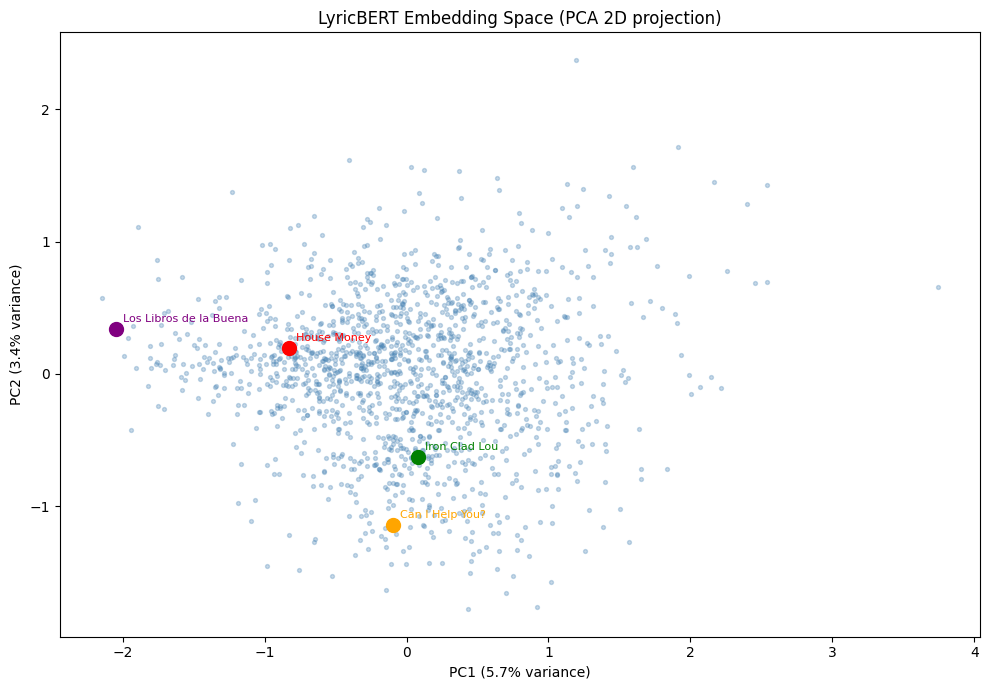

Total variance explained by 2 components: 9.0%
(Low % is expected — BERT embeddings are high-dimensional and resist 2D compression)


In [15]:
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=8, color='steelblue')

seeds = [
    ('House Money',                    'Baby Keem'),
    ('Iron Clad Lou',                  'Hum'),
    ("Can I Help You?",                'Amnesty'),
    ('Los Libros de la Buena Memoria', 'Invisible'),
]
colors = ['red', 'green', 'orange', 'purple']

for (title, artist), color in zip(seeds, colors):
    m = bert_df[
        (bert_df['track_name'].str.lower() == title.lower()) &
        (bert_df['artist'].str.lower()     == artist.lower())
    ]
    if not m.empty:
        idx = m.index[0]
        ax.scatter(coords[idx, 0], coords[idx, 1], color=color, s=100, zorder=5)
        ax.annotate(title[:22], (coords[idx, 0], coords[idx, 1]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points', color=color)

ax.set_title('LyricBERT Embedding Space (PCA 2D projection)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

print(f'Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}')
print('(Low % is expected — BERT embeddings are high-dimensional and resist 2D compression)')

## 4. Similarity Score Distribution: TF-IDF vs LyricBERT
LyricBERT scores behave very differently from TF-IDF, because all songs share a common semantic space. This allows even unrelated songs have moderate cosine similarit, meaning **raw scores are not comparable across models** — only rankings matter for comparison.

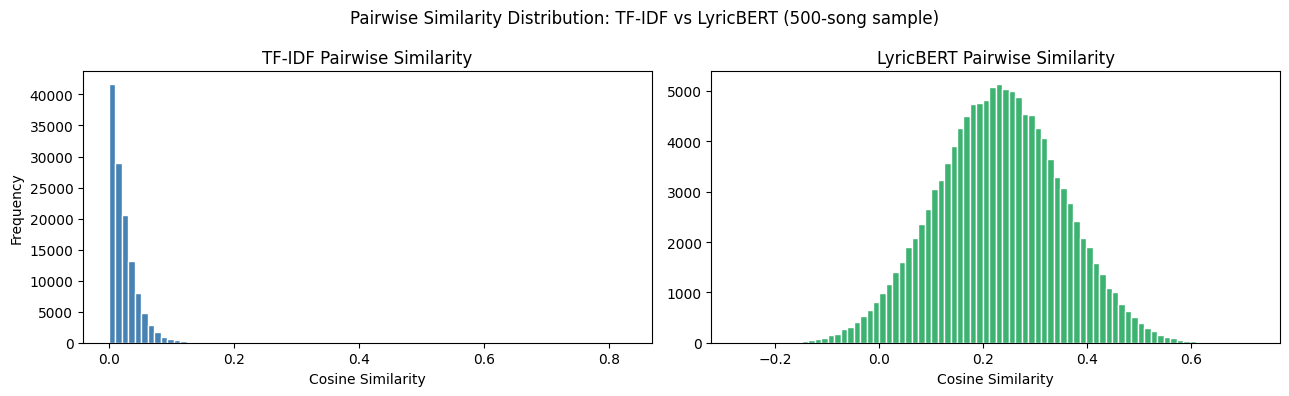

TF-IDF   :  mean=0.0237  median=0.0174  >0.3: 0.1%  >0.5: 0.0%  >0.9: 0.0%
LyricBERT:  mean=0.2304  median=0.2309  >0.3: 28.5%  >0.5: 1.1%  >0.9: 0.0%


In [16]:
sample_size = 500
rng = np.random.default_rng(42)
idx = rng.choice(len(bert_df), size=sample_size, replace=False)

bert_upper  = bert_sim[np.ix_(idx, idx)][np.triu_indices(sample_size, k=1)]
tfidf_upper = tfidf_sim[np.ix_(idx, idx)][np.triu_indices(sample_size, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(tfidf_upper, bins=80, color='steelblue',      edgecolor='white')
axes[0].set_title('TF-IDF Pairwise Similarity')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')

axes[1].hist(bert_upper,  bins=80, color='mediumseagreen', edgecolor='white')
axes[1].set_title('LyricBERT Pairwise Similarity')
axes[1].set_xlabel('Cosine Similarity')

plt.suptitle('Pairwise Similarity Distribution: TF-IDF vs LyricBERT (500-song sample)')
plt.tight_layout()
plt.show()

for label, arr in [('TF-IDF   ', tfidf_upper), ('LyricBERT', bert_upper)]:
    print(f"{label}:  mean={arr.mean():.4f}  median={np.median(arr):.4f}  "
          f">0.3: {(arr>0.3).mean()*100:.1f}%  "
          f">0.5: {(arr>0.5).mean()*100:.1f}%  "
          f">0.9: {(arr>0.9).mean()*100:.1f}%")

## 5. LyricBERT Recommendations

In [17]:
def show_bert_recs(seed_title, seed_artist=None, k=10):
    recs = recommend_songs(
        bert_df, bert_sim,
        seed_title=seed_title, seed_artist=seed_artist, k=k
    )
    print(f"\nSeed: '{seed_title}'{' by ' + seed_artist if seed_artist else ''}")
    print('-' * 60)
    print(recs.to_string(index=True))
    return recs

bert_grunge = show_bert_recs('Iron Clad Lou',                  'Hum')
bert_soul   = show_bert_recs("Can I Help You?",                'Amnesty')
bert_latin  = show_bert_recs('Los Libros de la Buena Memoria', 'Invisible')
bert_hiphop = show_bert_recs('House Money',                    'Baby Keem')


Seed: 'Iron Clad Lou' by Hum
------------------------------------------------------------
                        track_name                                 artist  similarity
0  You Don't Know The Shape I'm In                           MJ Lenderman    0.525735
1                      Peach Trees                  Ax and the Hatchetmen    0.510355
2                     Never Lonely                         Space Mountain    0.508147
3                          Cadence                         The Long Faces    0.506061
4                  Need You Around                          Smoking Popes    0.504594
5               Just Another Honky                                  Faces    0.484613
6                         Doghouse                  Trudy and the Romance    0.479031
7                       House Fire  Someone Still Loves You Boris Yeltsin    0.467930
8          Ease Yourself and Glide                          Parsley Sound    0.467269
9               I Know How You Get               

## 6. Four Model Comparison

In [18]:
def four_model_compare(seed_title, seed_artist=None, k=10):
    def safe_rec(fn, df, sim):
        try:
            return fn(df, sim, seed_title=seed_title, seed_artist=seed_artist, k=k)
        except ValueError:
            return None

    results = {
        'TF-IDF':    safe_rec(tfidf_recommend,  tfidf_df,  tfidf_sim),
        'LSA':       safe_rec(lsa_recommend,     lsa_df,    lsa_sim),
        'Chorus':    safe_rec(chorus_recommend,  chorus_df, chorus_sim),
        'LyricBERT': safe_rec(recommend_songs,   bert_df,   bert_sim),
    }

    print(f"\nSeed: '{seed_title}'{' by ' + seed_artist if seed_artist else ''}")
    header = f"{'#':<4}" + "".join(f" {('── ' + n + ' ──'):<36}" for n in results)
    print(header)
    print('-' * (4 + 36 * len(results)))

    for i in range(k):
        row = f"{i+1:<4}"
        for recs in results.values():
            if recs is None or i >= len(recs):
                row += f" {'[not found]':<36}"
            else:
                r     = recs.iloc[i]
                entry = f"{r['track_name'][:20]} / {r['artist'][:12]}"
                row  += f" {entry:<36}"
        print(row)

    return results

res_grunge = four_model_compare('Iron Clad Lou',                  'Hum')
res_soul   = four_model_compare("Can I Help You?",                'Amnesty')
res_latin  = four_model_compare('Los Libros de la Buena Memoria', 'Invisible')
res_hiphop = four_model_compare('House Money',                    'Baby Keem')


Seed: 'Iron Clad Lou' by Hum
#    ── TF-IDF ──                         ── LSA ──                            ── Chorus ──                         ── LyricBERT ──                     
----------------------------------------------------------------------------------------------------------------------------------------------------
1    Stand up and Win / Spymob            Never Lonely / Space Mounta          Stand up and Win / Spymob            You Don't Know The S / MJ Lenderman 
2    Never Lonely / Space Mounta          Space Fling / Sun Ra                 Faxing It In / Smushie               Peach Trees / Ax and the H          
3    Downtown / Varsity                   Stadium Arcadium / Red Hot Chil      UFO / The Juice Is                   Never Lonely / Space Mounta         
4    Hippies / flipturn                   Hell N Back / Bakar                  Belief / John Mayer                  Cadence / The Long Fac              
5    Rain / World's Expe                  Fruitless Tree

## 7. Jaccard Similarity Heatmaps

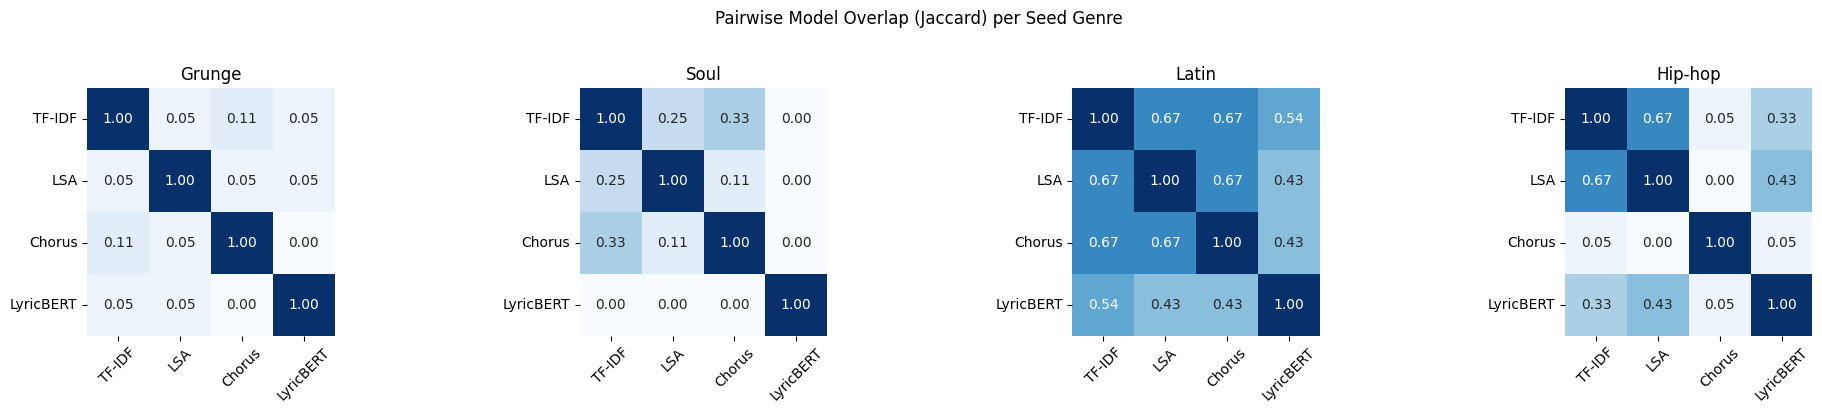

In [19]:
def jaccard(a, b):
    if a is None or b is None:
        return np.nan
    sa = set(zip(a['track_name'], a['artist']))
    sb = set(zip(b['track_name'], b['artist']))
    return len(sa & sb) / len(sa | sb)

def overlap_matrix(results):
    models = list(results.keys())
    mat = pd.DataFrame(index=models, columns=models, dtype=float)
    for a in models:
        for b in models:
            mat.loc[a, b] = 1.0 if a == b else jaccard(results[a], results[b])
    return mat

genre_results = [
    (res_grunge, 'Grunge'),
    (res_soul,   'Soul'),
    (res_latin,  'Latin'),
    (res_hiphop, 'Hip-hop'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (results, title) in zip(axes, genre_results):
    mat = overlap_matrix(results)
    sns.heatmap(
        mat.astype(float), annot=True, fmt='.2f',
        vmin=0, vmax=1, cmap='Blues',
        ax=ax, cbar=False, square=True
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Pairwise Model Overlap (Jaccard) per Seed Genre', y=1.02)
plt.tight_layout()
plt.show()

## 8. LyricBERT Unqiue Recommendations

In [20]:
def bert_unique(results, label):
    if results['LyricBERT'] is None:
        print(f"{label}: LyricBERT result not found\n")
        return

    bert_set  = set(zip(results['LyricBERT']['track_name'],
                        results['LyricBERT']['artist']))
    other_set = set()
    for name, recs in results.items():
        if name != 'LyricBERT' and recs is not None:
            other_set |= set(zip(recs['track_name'], recs['artist']))

    unique = bert_set - other_set
    shared = bert_set & other_set

    print(f"{label}")
    print(f"  Unique to LyricBERT:         {len(unique)}")
    for t, a in unique:
        print(f"    → {t} — {a}")
    print(f"  Shared with ≥1 other model:  {len(shared)}")
    print()

bert_unique(res_grunge, 'Grunge (Iron Clad Lou)')
bert_unique(res_soul,   'Soul (Can I Help You?)')
bert_unique(res_latin,  'Latin (Los Libros...)')
bert_unique(res_hiphop, 'Hip-hop (House Money)')

Grunge (Iron Clad Lou)
  Unique to LyricBERT:         9
    → Just Another Honky — Faces
    → Cadence — The Long Faces
    → House Fire — Someone Still Loves You Boris Yeltsin
    → Need You Around — Smoking Popes
    → I Know How You Get — Mk.gee
    → Peach Trees — Ax and the Hatchetmen
    → Ease Yourself and Glide — Parsley Sound
    → Doghouse — Trudy and the Romance
    → You Don't Know The Shape I'm In — MJ Lenderman
  Shared with ≥1 other model:  1

Soul (Can I Help You?)
  Unique to LyricBERT:         10
    → The Basement — Lunar Vacation
    → on the subject of apathy — Rehash
    → Marco — binki
    → Feeding the Family — Spacey Jane
    → Threw My Love Away — Okey Dokey
    → House Fire — Someone Still Loves You Boris Yeltsin
    → Is That the One — JW Francis
    → I — Column
    → Get On — Racoma
    → New Coat — White Denim
  Shared with ≥1 other model:  0

Latin (Los Libros...)
  Unique to LyricBERT:         2
    → Deixa Eu Dizer — Claudya
    → Surround Sound (feat.

## 9. Obserations